In [22]:
%matplotlib widget

In [23]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, 'src')

#from FDEM1D import FDEM1D
from showStitched import showStitchedModels

In [24]:
def FDEM1D(sgm, thk):
    """ 1D FDEM response         
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay
    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1
    Returns
    -------
    Array [OP, IP]
    """  
    # Set geometry
    Freq = 9000
    coilSpacing = [2, 4, 8]
    pcoilSpacing = [2.1, 4.1, 8.1]
    coilOrient = np.array(['H', 'V', 'P'])
    height = 0

    # Source and receivers geometry [x, y, z]
    source    = [0, 0, -height]
    receivers = [coilSpacing, np.zeros(len(coilSpacing)), -height]    
    preceivers = [pcoilSpacing, np.zeros(len(pcoilSpacing)), -height]

    # Depth and resistivity
    res_air = 1e6
    res = np.hstack((res_air, 1/sgm))
    depth = np.hstack((0, np.cumsum(thk)))
    # Empty array to store responses
    OUT = []

    if any(coilOrient == 'H'):

        H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                          verb=0)*(2j * np.pi * Freq * mu_0) 
        H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                         ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() 
        ip = (H_Hs/H_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'V'):
        V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                         ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() 
        ip = (V_Hs/V_Hp).real.amp() 
        OUT.append([op, ip])

    if any(coilOrient == 'P'):
        # Maybe put 0.1m in receiver offset
        P_Hs = ep.dipole(source, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                         verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = ep.dipole(source, preceivers, depth=[], res=[res_air], freqtime= Freq,
                         ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() 
        ip = (P_Hs/P_Hp).real.amp() 

        OUT.append([op, ip])

    return np.array(OUT).ravel()  

In [25]:
class FDEM1DModelling(pg.frameworks.Modelling):
    
    def __init__(self, nlay=3):
        self.nlay = nlay
        mesh = pg.meshtools.createMesh1DBlock(nlay)
        super().__init__()
        self.setMesh(mesh)
                
    def createStartModel(self, dataVals):
        startThicks = 2
        startSigma = 1/20
        
        # layer thickness properties
        self.setRegionProperties(0, startModel =  startThicks, trans = 'log')
        
        # electrical conductivity properties
        self.setRegionProperties(1, startModel = startSigma, trans = 'log')
        
        return super(FDEM1DModelling, self).createStartModel()
    
    def response(self, par):
        """ Compute response vector for a certain model [mod] 
        par = [thickness_1, thickness_2, ..., thickness_n, sigma_1, sigma_2, ..., sigma_n]
        """
        resp = FDEM1D(np.asarray(par)[self.nlay-1:self.nlay*2-1],   # sigma
                      np.asarray(par)[:self.nlay-1]                  # thickness
                      )
        return resp
    
    def response_mt(self, par, i=0):
        """Multi-threaded forward response."""
        return self.response(par)
    
    def createJacobian(self, par, dx=1e-4):
        """ compute Jacobian for a 1D model """
        resp = self.response(par)
        n_rows = len(resp) # number of data values in data vector
        n_cols = len(par) # number of model parameters
        J = self.jacobian() # we define first this as the jacobian
        J.resize(n_rows, n_cols)
        Jt = np.zeros((n_cols, n_rows))
        for j in range(n_cols):
            mod_plus_dx = par.copy()
            mod_plus_dx[j] += dx
            Jt[j,:] = (self.response(mod_plus_dx) - resp)/dx # J.T in col j
        for i in range(n_rows):
            J[i] = Jt[:,i]
        #print(self.jacobian())
        #print(J)
        #print(Jt)
        
    def drawModel(self, ax, model):
        pg.viewer.mpl.drawModel1D(ax = ax,
                                  model = model,
                                  plot = 'semilogx',
                                  xlabel = 'Electrical conductivity (S/m)',
                                  )
        ax.set_ylabel('Depth in (m)')

In [41]:
## Create a test model

pos = 10
nLayers = 3

x =  np.linspace(0,pos,pos, endpoint=False)
sigm_1 = 10/1000
sigm_2 = 20/1000
sigm_3 = 10/1000
thk_1 = x/9 + 2 #np.sin(np.pi/2*x/3) + 2
thk_2 = 4 - thk_1 #1/7*x + 1.5

models = np.zeros((pos, nLayers*2-1))
models[:,0] = thk_1
models[:,1] = thk_2
models[:,2] = sigm_1
models[:,3] = sigm_2
models[:,4] = sigm_3

nSoundings = pos

## Create test data

data_t = []

for p in range(pos):
    data_t.append(FDEM1D(models[p,2:], models[p,:2]))

<AxesSubplot:title={'center':'True model'}>

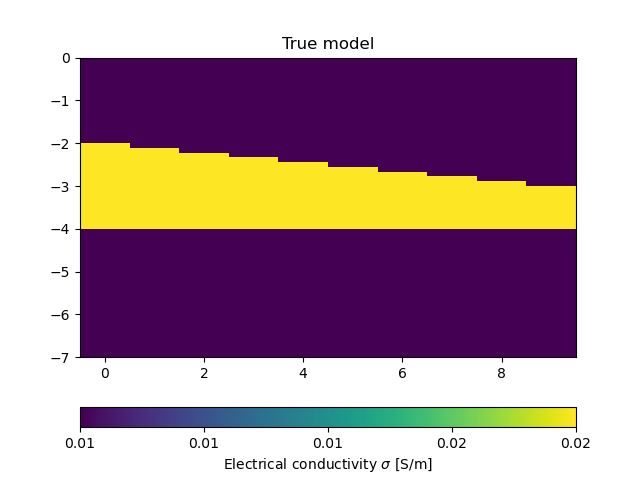

In [42]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]'}

showStitchedModels(models, zMax=7, title = 'True model', **inputs)

In [43]:
## Lets see inversion for each position in 1D

m0 = np.array([2, 2, 0.02, 0.02, 0.02])

models_est = np.zeros_like(models)

for p in range(pos):
    FOP = FDEM1DModelling()
    inv = pg.Inversion(FOP)
    data_true = data_t[p]
    relativeError = np.ones_like(data_true)*1e-3
    models_est[p] = inv.run(data_true, relativeError, startModel=m0, verbose=False)

22/02/24 - 15:34:27 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:27 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:27 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]


22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]


22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]


22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]
22/02/24 - 15:34:28 - pyGIMLi - INFO - Starting model set from given array. [2.   2.   0.02 0.02 0.02]


<AxesSubplot:title={'center':'Stitched 1D inversion'}>

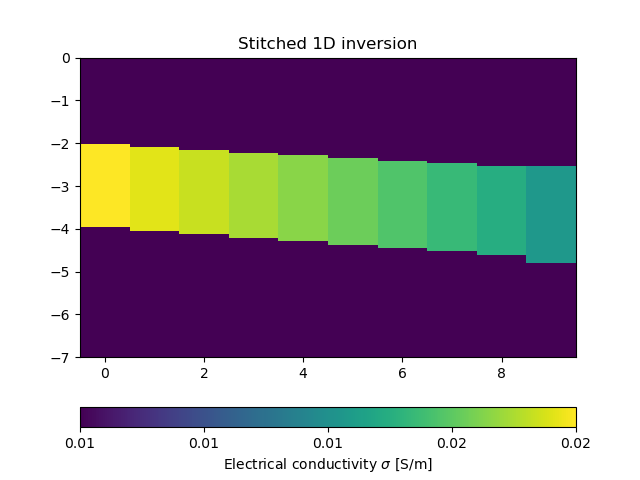

In [44]:
inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]'}

showStitchedModels(models_est, zMax=7, title = 'Stitched 1D inversion', **inputs)